# Report 5 Momentum Dumping Scenario

This notebook is a report-specific copy focused on creating a rigorous reaction-wheel saturation scenario and demonstrating active momentum dumping with magnetic torque rods. The nominal Starling environmental model is kept as the baseline; saturation is forced only in a clearly labeled stress test so the comparison is repeatable and physically traceable.

In [1]:
using LinearAlgebra, StaticArrays, Random, Statistics
using DifferentialEquations
using Rotations
using PythonPlot

include("../report4/safe_mode_gyrostat.jl")
include("../report4/environmental_perturbations.jl")
using .EnvironmentalPerturbations
include("../report4/orbit_gyrostat_environmental.jl")
include("../report4/attitude_control_starling_impl.jl")
include("momentum_dumping.jl")

print_run_summary (generic function with 1 method)

## Spacecraft Parameters

The spacecraft configuration starts from the existing report 5 setup and keeps the BCT RWP050 reaction-wheel limits: 6 mN m torque and 50 mN m s per wheel axis. The magnetorquer limit used later is 0.1 A m^2 per body-axis rod.

In [2]:
I_body = @SMatrix [
    0.282  0.0    0.0
    0.0    0.188  0.028
    0.0    0.028  0.174
]
e_panel = @SVector [0.0, 1.0, 0.0]

cfg = StarlingConfig(
    I_body     = I_body,
    e_panel    = e_panel,
    alt_km     = 480.0,
    τ_rw_max   = 6e-3,
    rho_rw_max = 50e-3,
    sun_vec_eci = @SVector([1.0, 0.0, 0.0]),
    aero = SpacecraftAeroProperties(
        Cd=2.2, area_m2=0.03, mass_kg=12.0,
        area_normal_body=e_panel,
        center_of_pressure_body_m=SVector(0.02, 0.0, 0.0),
    ),
    srp = SpacecraftSRPProperties(
        Cr=1.3, area_m2=0.03,
        area_normal_body=e_panel,
        center_of_pressure_body_m=SVector(0.02, 0.0, 0.0),
        sun_distance_au=1.0, eclipse=false,
    ),
)

StarlingConfig([0.282 0.0 0.0; 0.0 0.188 0.028; 0.0 0.028 0.174], [3.546099290780142 -0.0 -0.0; 0.0 5.449761964419944 -0.8769731896767726; 0.0 -0.8769731896767726 5.888248559258331], [0.0, 1.0, 0.0], 480.0, 6858.1363, 1.698664978058303, 0.0011116286202102177, 0.006, 0.05, [1.0, 0.0, 0.0], EarthEnvironment(3.986004418e14, 6.3781363e6, [0.0, 0.0, 7.2921159e-5], 3.614e-13, 700000.0, 88667.0, 4.56e-6), SpacecraftAeroProperties(2.2, 0.03, 12.0, [0.0, 1.0, 0.0], [0.02, 0.0, 0.0]), SpacecraftSRPProperties(1.3, 0.03, [0.0, 1.0, 0.0], [0.02, 0.0, 0.0], 1.0, false))

## Stress-Test Definition

Nominal environmental torques do not fill the wheels on a short report simulation. To create a rigorous demonstration, we first estimate the orbit-averaged nominal torque and then apply one explicit scale factor to that same modeled torque profile. The scale is chosen so a no-dump run should cross the per-axis wheel momentum limit during the demonstration window. This is a stress test, not a claim that nominal Starling saturates over four orbits.

In [3]:
Random.seed!(2026)

T_orbit = orbit_period_seconds_md(cfg)
T_demo = 4.0 * T_orbit
dt_ctrl = 5.0

qd = [1.0, 0.0, 0.0, 0.0]
q0 = [1.0, 0.0, 0.0, 0.0]
omega0 = zeros(3)
rho0 = zeros(3)

g_pd = PDGains(2.5, 3.5)
sigma_gyro = 2e-4
sigma_vec = 1e-3
V_mekf = (sigma_gyro^2) * I(3)

stress_estimate = estimate_stress_scale_for_saturation(
    cfg;
    q_ref=SVector{4,Float64}(qd),
    Tfinal=T_demo,
    target_fraction=1.20,
    samples=720,
)
stress_scale = stress_estimate.scale

println("Orbit period = $(round(T_orbit, digits=2)) s")
println("Demo duration = $(round(T_demo / T_orbit, digits=2)) orbits")
println("Mean nominal environmental torque [N*m] = ", stress_estimate.mean_torque_body_Nm)
println("Nominal per-axis momentum growth over demo [N*m*s] = ", stress_estimate.nominal_axis_growth_Nms)
println("Stress-test disturbance scale = ", round(stress_scale; sigdigits=5))

Orbit period = 5652.23 s
Demo duration = 4.0 orbits
Mean nominal environmental torque [N*m] = [-4.693006678471818e-8, 7.936650732378618e-9, 1.5453340643610744e-9]
Nominal per-axis momentum growth over demo [N*m*s] = [0.0010610389143486992, 0.00017943923487852303, 3.4938360208975e-5]
Stress-test disturbance scale = 56.548


## Three Comparison Runs

The baseline run uses the nominal disturbance model and no dumping. The stressed no-dump run uses the scaled disturbance and should saturate the wheel momentum. The stressed dumping run uses the same disturbance scale plus a magnetic unloading law. The controller is fed truth and uses known external-torque feedforward here so the result isolates wheel momentum buildup and unloading from estimator tuning; MEKF histories are still propagated by the simulation helper for consistency with the report 4 structure.

In [4]:
common = (; 
    Tfinal=T_demo,
    dt=dt_ctrl,
    q0=q0,
    omega0=omega0,
    rho0=rho0,
    qd=qd,
    g=g_pd,
    sigma_gyro=sigma_gyro,
    sigma_vec=sigma_vec,
    V_mekf=V_mekf,
    control_from_truth=true,
    control_gyro_lpf_tau=2.0,
    sigma_bias_walk=1e-7,
    feedforward_external_torque=true,
)

baseline = simulate_momentum_dumping(
    cfg;
    common...,
    rng=MersenneTwister(101),
    disturbance_scale=1.0,
    enable_dumping=false,
)

stressed_no_dump = simulate_momentum_dumping(
    cfg;
    common...,
    rng=MersenneTwister(101),
    disturbance_scale=stress_scale,
    enable_dumping=false,
)

stressed_dump = simulate_momentum_dumping(
    cfg;
    common...,
    rng=MersenneTwister(101),
    disturbance_scale=stress_scale,
    enable_dumping=true,
    dump_gain=2.0e-4,
    dipole_max=0.1,
    dump_deadband=2e-3,
)

(t = 0.0:5.0:22610.0, q_hist = [1.0 1.0 … 1.0 1.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], qh_hist = [0.9950826307272047 0.9582238709301398 … -0.8404934024673559 -0.8218261500997305; 0.0910089831269162 -0.28267187062514193 … -0.5418161609141136 -0.5697364922085095; -0.023020641362447806 0.013506388390436984 … 0.0002546565029799894 0.000987437937797057; 0.031590712028881925 -0.041487398202208536 … 0.002454247584155617 -0.0010646241201465738], omega_hist = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], beta_hist = [0.0 -6.981846117914871e-8 … -2.5810738045291577e-5 -2.6001045469226973e-5; 0.0 7.320398946121565e-8 … 1.0750748040281863e-5 1.1051209100647478e-5; 0.0 1.3167123651287413e-7 … -1.4476591482981685e-5 -1.4707762669285522e-5], betahat_hist = [0.0 0.07245551599081557 … -0.013465181046697174 -0.013465217068550554; 0.0 -0.0061650363523236655 … 0.0008526649952278087 0.0008528419016432039; 0.0 0.015156140962492848 … -0.0009493598410100423 -0.00094921328220

In [5]:
summaries = [
    run_summary("Baseline nominal/no dump", baseline, cfg),
    run_summary("Stress test/no dump", stressed_no_dump, cfg),
    run_summary("Stress test/with magnetic dumping", stressed_dump, cfg),
]

for s in summaries
    print_run_summary(s)
end

Baseline nominal/no dump
  disturbance scale: 1.0
  dumping enabled: false
  max |rho_i|: 0.001061 N*m*s / 0.05
  first saturation: none
  saturated time fraction: 0.0%
  RMS pointing: 0.0 deg
  max |m_i|: 0.0 A*m^2 / 0.1
  B-field range: 25.1 to 49.89 uT
Stress test/no dump
  disturbance scale: 56.548
  dumping enabled: false
  max |rho_i|: 0.05 N*m*s / 0.05
  first saturation: 18605.0 s
  saturated time fraction: 17.73%
  RMS pointing: 0.0 deg
  max |m_i|: 0.0 A*m^2 / 0.1
  B-field range: 25.1 to 49.89 uT
Stress test/with magnetic dumping
  disturbance scale: 56.548
  dumping enabled: true
  max |rho_i|: 0.026117 N*m*s / 0.05
  first saturation: none
  saturated time fraction: 0.0%
  RMS pointing: 0.0 deg
  max |m_i|: 0.1 A*m^2 / 0.1
  B-field range: 25.1 to 49.89 uT


## Saturation And Dumping Evidence

The key evidence is whether the stress test causes wheel momentum to hit the 50 mN m s limit and whether magnetic dumping lowers or bounds that momentum while attitude pointing remains controlled. The magnetic-field sanity check should stay in the LEO range of tens of microtesla.

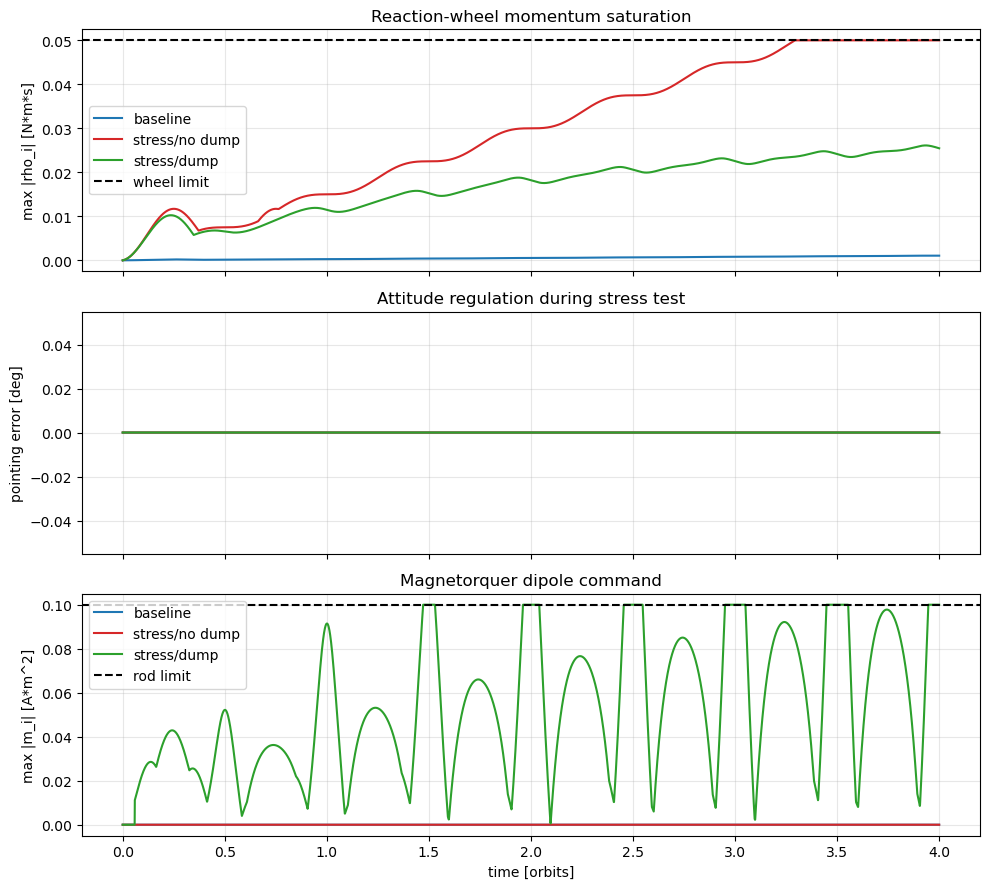

In [6]:
runs = [
    (baseline, "baseline", "tab:blue"),
    (stressed_no_dump, "stress/no dump", "tab:red"),
    (stressed_dump, "stress/dump", "tab:green"),
]

fig, axs = subplots(3, 1, figsize=(10, 9), sharex=true)

for (sol, label, color) in runs
    torbits = collect(sol.t) ./ T_orbit
    rho_max = [maximum(abs.(sol.rho_hist[:, k])) for k in axes(sol.rho_hist, 2)]
    dipole_max_hist = [maximum(abs.(sol.dipole_hist[:, k])) for k in axes(sol.dipole_hist, 2)]
    axs[0].plot(torbits, rho_max, label=label, color=color)
    axs[1].plot(torbits, sol.ang_hist, label=label, color=color)
    axs[2].plot(torbits, dipole_max_hist, label=label, color=color)
end

axs[0].axhline(cfg.rho_rw_max, color="black", linestyle="--", linewidth=1.5, label="wheel limit")
axs[0].set_ylabel("max |rho_i| [N*m*s]")
axs[0].set_title("Reaction-wheel momentum saturation")
axs[0].grid(true, alpha=0.3)
axs[0].legend(loc="best")

axs[1].set_ylabel("pointing error [deg]")
axs[1].set_title("Attitude regulation during stress test")
axs[1].grid(true, alpha=0.3)

axs[2].axhline(0.1, color="black", linestyle="--", linewidth=1.5, label="rod limit")
axs[2].set_ylabel("max |m_i| [A*m^2]")
axs[2].set_xlabel("time [orbits]")
axs[2].set_title("Magnetorquer dipole command")
axs[2].grid(true, alpha=0.3)
axs[2].legend(loc="best")

fig.tight_layout()
mkpath("figs")
savefig("figs/momentum_dumping_stress_test.png", bbox_inches="tight")
display(fig)

In [7]:
no_dump_summary = summaries[2]
dump_summary = summaries[3]

println("Validation checks:")
println("  stressed no-dump reaches saturation: ", no_dump_summary.first_saturation_s !== nothing)
println("  dumping reduces max wheel momentum: ", dump_summary.max_abs_rho_Nms < no_dump_summary.max_abs_rho_Nms)
println("  dipole command respects rod limit: ", dump_summary.max_dipole_Am2 <= dump_summary.dipole_limit_Am2 + 1e-12)
println("  dipole B-field remains LEO-like: ", 10.0 <= dump_summary.mean_B_uT <= 80.0)

Validation checks:
  stressed no-dump reaches saturation: true
  dumping reduces max wheel momentum: true
  dipole command respects rod limit: true
  dipole B-field remains LEO-like: true


## MeshCat three-scenario visualization

Interactive 3D replay of a rectangular prism bus (6U-like 0.3 x 0.1 x 0.1 m) for:

1. **Disturbance only** — scaled environmental torque, reaction-wheel torque forced to zero (`wheel_torque_mode=:none`), so the body tumbles.
2. **Reaction wheels** — same stress, wheels cancel disturbances with feedforward until momentum saturates; no magnetorquers.
3. **Magnetorquers** — same stress with magnetic momentum dumping; attitude stays regulated while wheel momentum is bounded.

**Setup:** install packages once if needed: `import Pkg; Pkg.add(["MeshCat", "GeometryBasics", "CoordinateTransformations", "Colors"])`. Run this notebook from the `report5/` folder. A browser tab opens; three animations play back-to-back with short pauses. Close the tab or stop the kernel when finished.

For **button-driven replay** and sliders (WebIO + Interact), use the **Interactive MeshCat** section below instead of this cell.

In [8]:
using MeshCat
using GeometryBasics
using CoordinateTransformations
using Colors

include("momentum_dumping_meshcat.jl")

# Replay uses the same T_demo and dt_ctrl as the plots above (full four-orbit window).
mesh_result = run_three_meshcat_demos(
    cfg;
    T_demo=T_demo,
    dt_ctrl=dt_ctrl,
    qd=Vector{Float64}(qd),
    stress_scale=stress_scale,
    g_pd=g_pd,
    rng=MersenneTwister(101),
    subsample=25,
    frame_pause=0.015,
    # >1.0 slows each frame and the gap between scenarios (e.g. 3.0 ≈ 3× slower).
    playback_slowdown=3.0,
    pause_between_scenarios=1.5,
)

[ Info: Listening on: 127.0.0.1:8700, thread id: 1
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
└ http://127.0.0.1:8700
[ Info: MeshCat scenario 1/3: disturbance only (no wheel torque)
[ Info: MeshCat scenario 2/3: reaction wheels (saturate under stress, no magnetic dumping)
[ Info: MeshCat scenario 3/3: wheels + magnetorquers (momentum dumping, attitude recovery)


(vis = MeshCat Visualizer with path /meshcat at http://127.0.0.1:8700, sol_disturb = (t = 0.0:5.0:22610.0, q_hist = [1.0 0.9999999982412683 … -0.12632210736712066 -0.3689666237655994; 0.0 -2.2569557888035876e-10 … 0.2431743258334461 0.6414201165739832; 0.0 5.9231061384817045e-5 … 0.3536314811611527 0.2398750164130737; 0.0 3.0240377699266277e-6 … 0.894345429896943 0.6284137499307761], qh_hist = [0.9950826307272047 0.9582205457331713 … 0.04073924297865683 0.11386595554630133; 0.0910089831269162 -0.28268922560988613 … -0.38383206685369164 -0.8075532875069129; -0.023020641362447806 0.013390426587373903 … -0.7835161913343595 -0.49973336836454396; 0.031590712028881925 -0.04148353811712074 … -0.4869452088821171 -0.29181979464616864], omega_hist = [0.0 -3.6111292597127e-10 … 0.00014780856783987568 0.0006309652032695776; 0.0 4.738484914227164e-5 … -0.13502690577839133 -0.13539044061219863; 0.0 2.4192302094220188e-6 … 0.17659900937792614 0.17659848412505974], beta_hist = [0.0 -6.981846117914871e

## Interactive MeshCat (buttons and sliders)

Optional in-notebook controls (**WebIO** + **Interact**): replay each scenario on demand and tune **playback slowdown** and **subsample** without running all three clips in sequence.

**You can skip WebIO entirely** if you only want the 3D bus: use the auto-run cell above (`run_three_meshcat_demos`) or set `open_external=true` in the code below—MeshCat always opens a normal browser tab. WebIO is only for **embedding** the buttons and iframe inside the notebook.

**Packages:** `import Pkg; Pkg.add(["WebIO", "Interact"])` once, then restart the kernel.

**If you see “WebIO Jupyter extension was not detected”:** Julia packages are not enough; Jupyter needs the WebIO frontend. After `include("momentum_dumping_meshcat.jl")`, run once in Julia (then fully quit and restart Jupyter / VS Code):

```julia
install_webio_jupyter!()
```

Or manually: `using WebIO, IJulia` then `WebIO.install_jupyter_nbextension()` and `WebIO.install_notebook_config()` (see [WebIO IJulia docs](https://juliagizmos.github.io/WebIO.jl/stable/providers/ijulia/)). For **JupyterLab**, use `WebIO.install_jupyter_labextension()` instead. The `jupyter` on your PATH must be the same one your editor uses.

Run the code cell below after the MeshCat include cell. Each button restarts that simulation’s replay from **t = 0** (same initial attitude as the auto-run block above); the three trajectories are still three separate simulations, not one stitched time history.

In [9]:
import Pkg
Pkg.add(["WebIO", "IJulia"])
using WebIO, IJulia

interactive_mesh = interactive_meshcat_scenarios(
    cfg;
    T_demo=T_demo,
    dt_ctrl=dt_ctrl,
    qd=Vector{Float64}(qd),
    stress_scale=stress_scale,
    g_pd=g_pd,
    rng=MersenneTwister(101),
    subsample=25,
    frame_pause=0.015,
    default_playback_slowdown=8.0,
    open_external=true,
)
interactive_mesh.ui

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\xtian\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\xtian\.julia\environments\v1.12\Manifest.toml`


WebIO._IJuliaInit()

[ Info: Listening on: 127.0.0.1:8701, thread id: 1
┌ Info: MeshCat server started. You can open the visualizer by visiting the following URL in your browser:
└ http://127.0.0.1:8701
  Julia 1.12 has introduced more strict world age semantics for global bindings.
  !!! This code may malfunction under Revise.
  !!! This code will error in future versions of Julia.
Hint: Add an appropriate `invokelatest` around the access to this binding.
To make this warning an error, and hence obtain a stack trace, use `julia --depwarn=error`.


LoadError: Function slider was about to overflow: check the signature

## Modeling Notes And Limitations

The disturbance multiplier is a deliberate stress-test device. It preserves the modeled gravity-gradient and aerodynamic disturbance directions but compresses a days-long saturation process into a short demonstration window. The magnetic field is an Earth-centered dipole model, not full IGRF; this is sufficient to show the core control constraint that magnetic torque is always perpendicular to the local field. A flight-grade analysis should replace the dipole model with IGRF, include eclipse and time-varying solar geometry if SRP is used, and tune the unloading gain against a full estimator-in-the-loop simulation.